# Local L-C2ST at a frozen synthetic observation

The primary observation was fixed before the diagnostic and has
`c_ctx2th` equal to the matched 7D value, so both models are correctly
specified for this comparison. Each track uses 20,000 additional independent
prior-predictive simulations. Null rejection indicates a local posterior
mismatch; non-rejection is not proof of physiological validity.

**Training-scale note.** The main panels below are the FINAL_SCALE (32768)
reference. A later section adds INTERMEDIATE_SCALE (8192) local L-C2ST on the
**same** frozen \(x_o\) and calibration bank. Because 8192 has only one
estimator per track while 32768 has five members, that contrast is an
**asymmetric descriptive scale contrast**, not a causal claim that simulation
count alone improves L-C2ST.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "S4_sbi").exists() else cwd.parent.parent
SRC = PROJECT_ROOT / "S4_sbi" / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "figure10_8d_7d"
assert os.environ.get("CONDA_DEFAULT_ENV") == "neurolib"
print("environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("python:", sys.executable)
print("results:", RESULTS)

environment: neurolib
python: C:\Users\YUS190\AppData\Local\anaconda3\python.exe
results: D:\Year3_Mao_Projects\sleep_loop\S4_sbi\results\figure10_8d_7d


In [2]:
manifest = json.loads((RESULTS / "diagnostics" / "ppc" / "primary_observation_manifest.json").read_text())
display(pd.Series(manifest))
tables = []
for track in ("8d", "7d"):
    frame = pd.read_csv(RESULTS / "diagnostics" / "lc2st" / track / "lc2st_summary.csv")
    if "training_scale" not in frame.columns:
        frame["training_scale"] = 32768
    tables.append(frame)
display(Markdown("### FINAL_SCALE (32768) reference — legacy `lc2st/{track}/`"))
display(pd.concat(tables, ignore_index=True))

created_utc                                         2026-07-31T11:22:37.824338+00:00
identifier                                          canonical_v8a_local_best_primary
theta_full_8d                      [3.5213182430642145, 2.8850644250475654, 35.85...
simulator_seed                                                               9580001
same_observation_for_8d_and_7d                                                  True
c_ctx2th_equals_frozen_7d_value                                                 True
path                               diagnostics/ppc/primary_observation/8d/primary...
sha256                             1bd70e584024bbf3a7f05397a8d76f637455ece5f16d33...
preregistration_hash               a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
dtype: object

### FINAL_SCALE (32768) reference — legacy `lc2st/{track}/`

,created_utc,track,estimator,calibration_cases,local_posterior_samples,score_observed,null_q95,p_value,reject_alpha_0p05,classifier_seed,runtime_s,classifier_sha256,preregistration_hash,training_scale
0,2026-07-31T02:07:25.489192+00:00,8d,ensemble,20000,10000,0.129714,0.024163,0.0,True,9594001,3400.972876,d3ed8da9eb8529103c5461e9da67df852721f118f0bfe7...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
1,2026-07-31T03:03:00.734596+00:00,8d,member_1,20000,10000,0.169712,0.035377,0.0,True,9595010,3334.950489,c307aa9c6a00211c3f349f2f7792c13d9409448b0c4721...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
2,2026-07-31T03:58:11.524564+00:00,8d,member_2,20000,10000,0.154405,0.034331,0.0,True,9596019,3310.477774,c087ec6ff4f576ebbb6975fc657f73b6be537e93b1a372...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
3,2026-07-31T04:56:36.057383+00:00,8d,member_3,20000,10000,0.149582,0.038378,0.0,True,9597028,3504.183144,1644377b4e3217b919a83c5ba46596aff9a99f8aef427b...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
4,2026-07-31T05:50:56.098567+00:00,8d,member_4,20000,10000,0.177282,0.016021,0.0,True,9598037,3259.701390,695bcd3de3885bca4197a449942abbe6cf27802ea54d41...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
5,2026-07-31T06:46:22.263502+00:00,8d,member_5,20000,10000,0.141439,0.025495,0.0,True,9599046,3325.825522,3dedbc68a7d37861d0bd6a253a938377baa1bf5d6ba041...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
6,2026-07-31T07:30:15.286409+00:00,7d,ensemble,20000,10000,0.159474,0.021744,0.0,True,9595001,2632.030922,20487bdda5b7d0b1d92e9cde33a8e642be0ab9de02262d...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
7,2026-07-31T08:16:36.416213+00:00,7d,member_1,20000,10000,0.174615,0.030174,0.0,True,9596010,2780.801623,8f96957af8a7406e451b4d1623921a4b16656fe525dc2a...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
8,2026-07-31T09:02:55.167383+00:00,7d,member_2,20000,10000,0.104563,0.025416,0.0,True,9597019,2778.404835,736c0991a2a93af22a2b76616e9eb4917e4a7787fa8939...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768
9,2026-07-31T09:50:32.049562+00:00,7d,member_3,20000,10000,0.154209,0.031213,0.0,True,9598028,2856.543759,62205e5b2fd020018b8f10f8f4f8b373684944f552d138...,a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...,32768


## Individual networks versus ensemble

Bars show observed classifier statistics; black markers show the 95% null
threshold. The ensemble must be interpreted as an equal mixture, not a product
of member densities.

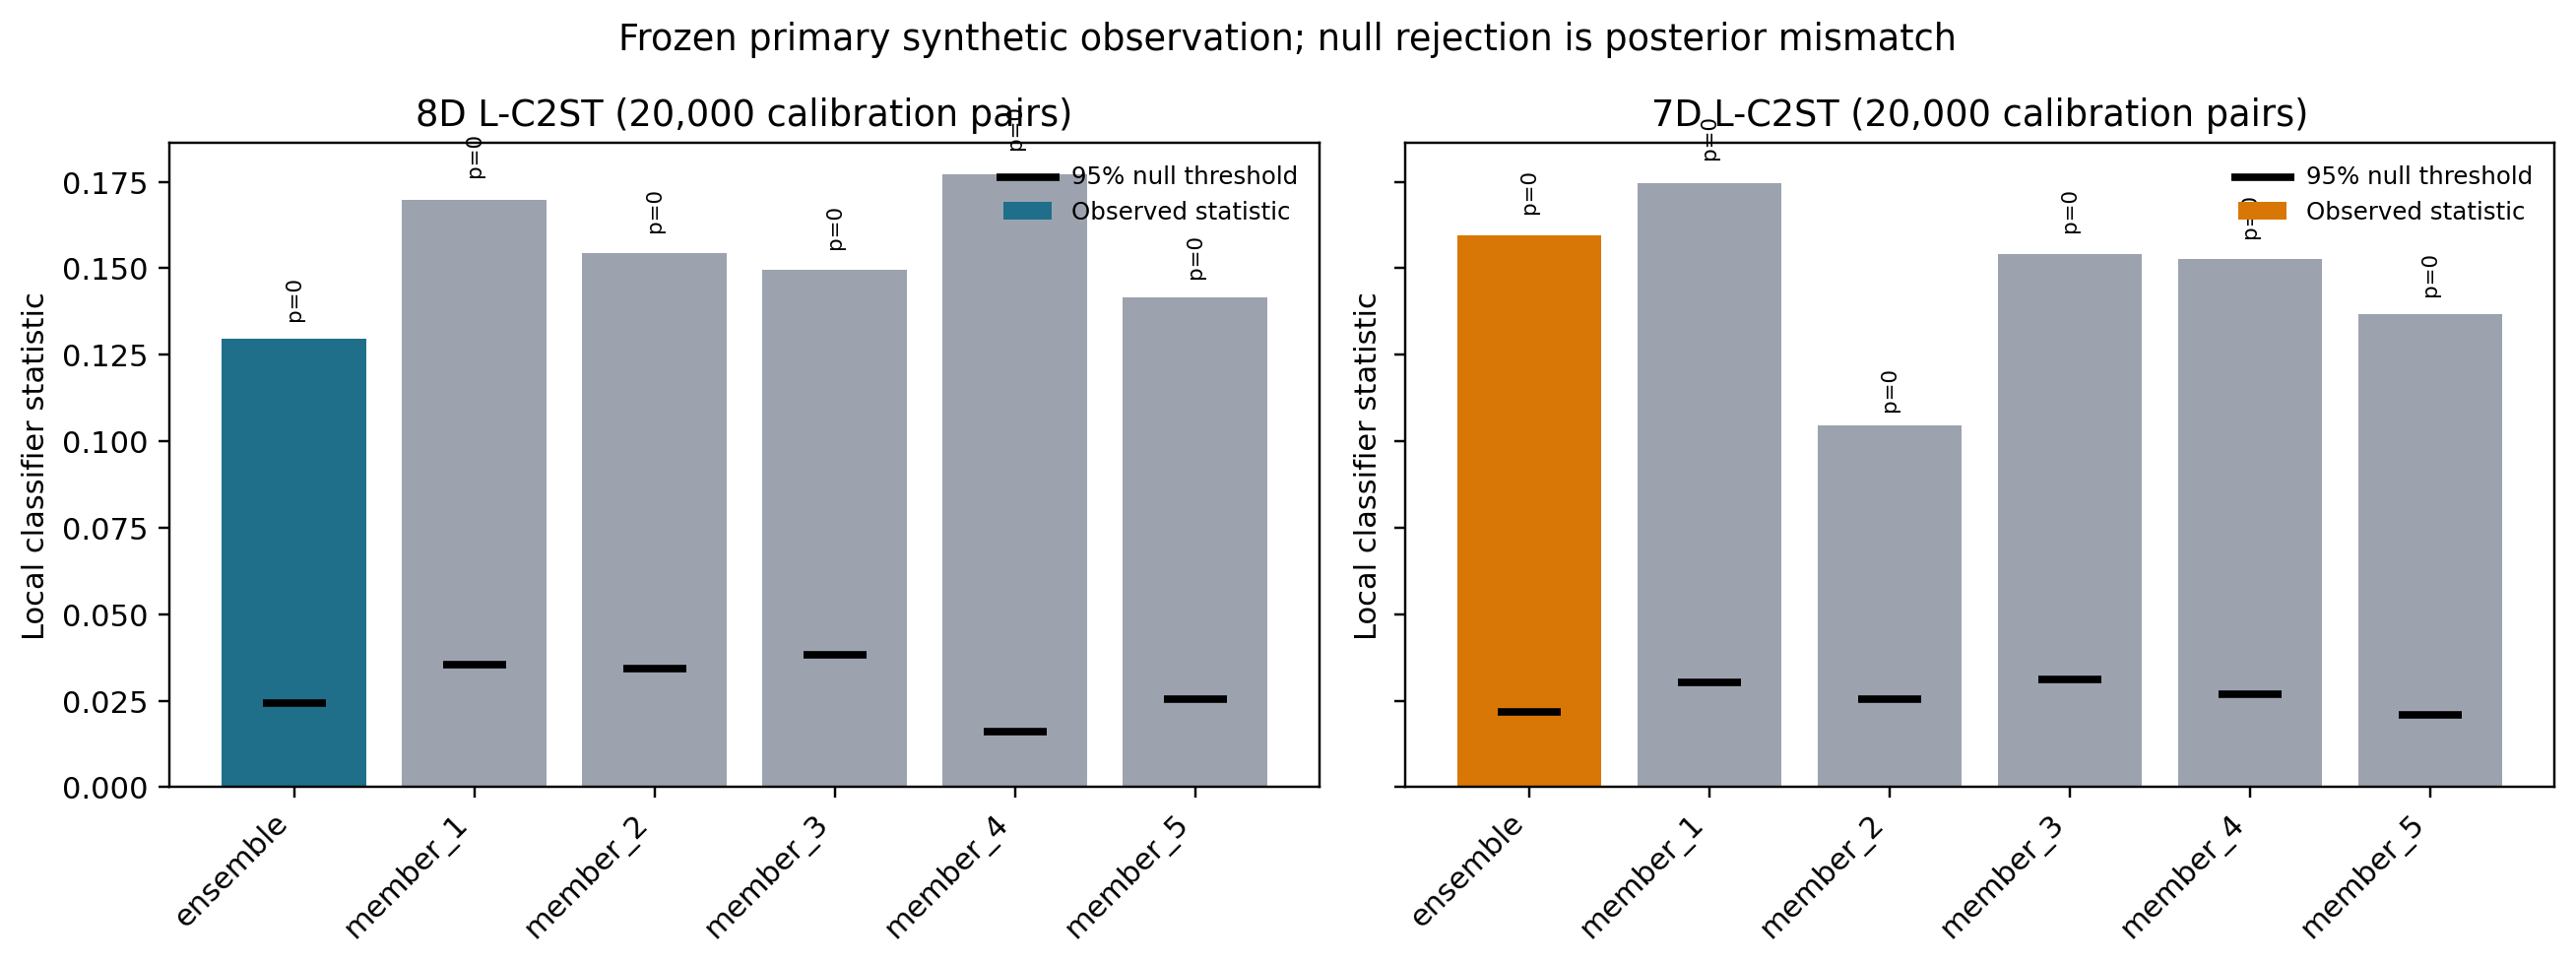

In [3]:
figure = RESULTS / "figures" / "figure10_lc2st_8d_7d.png"
assert figure.exists() and figure.stat().st_size > 1000
display(Image(filename=str(figure)))

## Training-size contrast: 8192 vs 32768

Same primary observation and same 20k L-C2ST calibration bank; only the trained
posterior checkpoint scale changes.

| Comparison | Role |
|---|---|
| `member_1 @8192` vs `member_1 @32768` | **Primary** — matched single-estimator contrast |
| `ensemble @8192` vs `ensemble @32768` | **Secondary** — asymmetric (\(K=1\) vs \(K=5\)); at 8192, ensemble≡member_1 |

Do **not** interpret reject/non-reject flips here as a causal \(n_{\mathrm{sim}}\) effect.

<>:29: SyntaxWarning: invalid escape sequence '\('
<>:65: SyntaxWarning: invalid escape sequence '\('
<>:65: SyntaxWarning: invalid escape sequence '\)'
<>:71: SyntaxWarning: invalid escape sequence '\('
<>:29: SyntaxWarning: invalid escape sequence '\('
<>:65: SyntaxWarning: invalid escape sequence '\('
<>:65: SyntaxWarning: invalid escape sequence '\)'
<>:71: SyntaxWarning: invalid escape sequence '\('
C:\Users\YUS190\AppData\Local\Temp\ipykernel_47996\3490489523.py:29: SyntaxWarning: invalid escape sequence '\('
  display(Markdown("### Secondary: ensemble (asymmetric \(K\))"))
C:\Users\YUS190\AppData\Local\Temp\ipykernel_47996\3490489523.py:65: SyntaxWarning: invalid escape sequence '\('
  lines.append(f"- **{track} member_1:** reject@8192 → keep@32768 (descriptive improvement; not causal \(n_{{sim}}\)).")
C:\Users\YUS190\AppData\Local\Temp\ipykernel_47996\3490489523.py:65: SyntaxWarning: invalid escape sequence '\)'
  lines.append(f"- **{track} member_1:** reject@8192 → keep@32768 

created_utc                              2026-08-02T06:09:21.913224+00:00
csv                     diagnostics/lc2st/scale_contrast_8192_vs_32768...
primary_comparison      member_1 @8192 vs member_1 @32768 (matched sin...
secondary_comparison    ensemble @8192 (≡member_1, K=1) vs ensemble @3...
n_rows                                                                 16
preregistration_hash    a4eb07b24f84454ae85b3321c920d5f50d452d6314a3db...
dtype: object

### Primary: matched `member_1`

,track,training_scale,n_members,p_value,reject_alpha_0p05,score_observed,null_q95
0,7d,8192,1,0.0,True,0.229475,0.026002
1,7d,32768,5,0.0,True,0.174615,0.030174
2,8d,8192,1,0.0,True,0.190380,0.048883
3,8d,32768,5,0.0,True,0.169712,0.035377


### Secondary: ensemble (asymmetric \(K\))

,track,training_scale,n_members,p_value,reject_alpha_0p05,score_observed,null_q95
0,7d,8192,1,0.0,True,0.218224,0.030170
1,7d,32768,5,0.0,True,0.159474,0.021744
2,8d,8192,1,0.0,True,0.219664,0.019847
3,8d,32768,5,0.0,True,0.129714,0.024163


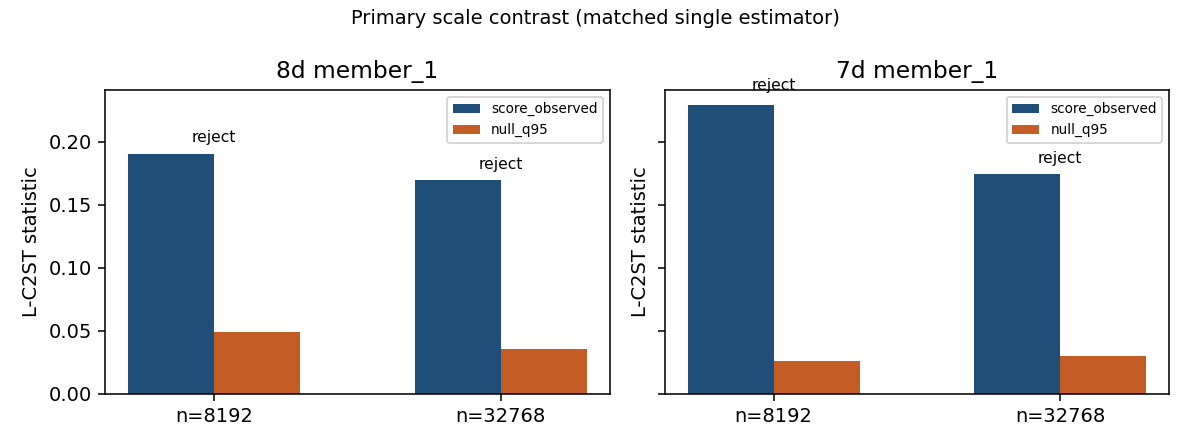

### Descriptive takeaway
- **8d member_1:** reject at both 8192 and 32768 (no decision change).
- **7d member_1:** reject at both 8192 and 32768 (no decision change).

Secondary ensemble contrast remains \(K=1\) vs \(K=5\) and is not a pure size effect.

In [4]:
import matplotlib.pyplot as plt

contrast_csv = RESULTS / "diagnostics" / "lc2st" / "scale_contrast_8192_vs_32768.csv"
manifest_path = RESULTS / "diagnostics" / "lc2st" / "scale_contrast_8192_vs_32768_manifest.json"
if not contrast_csv.is_file():
    display(Markdown(
        "**Scale-contrast artifacts not found yet.** Run from `S4_sbi/src`:\n\n"
        "```python\n"
        "from sleep_sbi.figure10_diagnostics import run_lc2st, build_lc2st_scale_contrast\n"
        "from sleep_sbi.figure10_protocol import INTERMEDIATE_SCALE\n"
        "run_lc2st('8d', INTERMEDIATE_SCALE)\n"
        "run_lc2st('7d', INTERMEDIATE_SCALE)\n"
        "build_lc2st_scale_contrast()\n"
        "```\n"
    ))
else:
    contrast = pd.read_csv(contrast_csv)
    if manifest_path.is_file():
        display(pd.Series(json.loads(manifest_path.read_text(encoding="utf-8"))))

    primary = contrast[contrast["estimator"] == "member_1"].copy()
    secondary = contrast[contrast["estimator"] == "ensemble"].copy()
    cols = [
        "track", "training_scale", "n_members", "p_value", "reject_alpha_0p05",
        "score_observed", "null_q95",
    ]
    display(Markdown("### Primary: matched `member_1`"))
    display(primary[cols].sort_values(["track", "training_scale"]).reset_index(drop=True))
    display(Markdown("### Secondary: ensemble (asymmetric \(K\))"))
    display(secondary[cols].sort_values(["track", "training_scale"]).reset_index(drop=True))

    # Compact bar: score_observed vs null_q95 for member_1
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), sharey=True)
    for ax, track in zip(axes, ("8d", "7d")):
        sub = primary[primary.track == track].sort_values("training_scale")
        x = np.arange(len(sub))
        ax.bar(x - 0.15, sub["score_observed"], 0.3, label="score_observed", color="#1f4e79")
        ax.bar(x + 0.15, sub["null_q95"], 0.3, label="null_q95", color="#c45c26")
        ax.set_xticks(x)
        ax.set_xticklabels([f"n={int(s)}" for s in sub["training_scale"]])
        ax.set_title(f"{track} member_1")
        ax.set_ylabel("L-C2ST statistic")
        for i, rej in enumerate(sub["reject_alpha_0p05"].tolist()):
            ax.text(i, max(sub["score_observed"].iloc[i], sub["null_q95"].iloc[i]) * 1.05,
                    "reject" if rej else "keep", ha="center", fontsize=8)
        ax.legend(fontsize=7)
    fig.suptitle("Primary scale contrast (matched single estimator)", fontsize=10)
    fig.tight_layout()
    out_fig = RESULTS / "figures" / "figure10_lc2st_scale_contrast_member1.png"
    out_fig.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_fig, dpi=140)
    fig.savefig(out_fig.with_suffix(".svg"))
    plt.close(fig)
    display(Image(filename=str(out_fig)))

    # One-line descriptive conclusion
    piv = primary.pivot(index="track", columns="training_scale", values="reject_alpha_0p05")
    lines = []
    for track in ("8d", "7d"):
        if 8192 in piv.columns and 32768 in piv.columns:
            r8, r32 = bool(piv.loc[track, 8192]), bool(piv.loc[track, 32768])
            if r8 and r32:
                lines.append(f"- **{track} member_1:** reject at both 8192 and 32768 (no decision change).")
            elif r8 and not r32:
                lines.append(f"- **{track} member_1:** reject@8192 → keep@32768 (descriptive improvement; not causal \(n_{{sim}}\)).")
            elif (not r8) and r32:
                lines.append(f"- **{track} member_1:** keep@8192 → reject@32768 (descriptive worsening; check K-confound / noise).")
            else:
                lines.append(f"- **{track} member_1:** keep at both scales.")
    display(Markdown("### Descriptive takeaway\n" + "\n".join(lines) +
                     "\n\nSecondary ensemble contrast remains \(K=1\) vs \(K=5\) and is not a pure size effect."))